<a href="https://colab.research.google.com/github/Covpet/Hospital-readmission-prediction/blob/main/hospital_readmission_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reducing 30-Day Hospital Readmissions, End-to-End Analysis

**Goal:** find out which patients are most likely to come back to hospital within 30 days of discharge, and what drives it, so a care team can focus follow-up on the right people.

**Dataset:** *Diabetes 130-US Hospitals (1999–2008)* from the UCI Machine Learning Repository — about 100,000 real, de-identified hospital encounters from 130 US hospitals. Each row holds payer code, admission and discharge details, diagnoses (ICD-9), medications, and the number of ER, inpatient and outpatient visits in the previous year.

**What this notebook does**
1. Load the data (downloads automatically)
2. First look and data quality checks
3. Data cleaning
4. Exploratory data analysis (EDA)
5. Feature engineering
6. Frequent ER users, a second problem
7. Preprocessing and transformations
8. Machine learning: three models compared
9. Threshold tuning and confusion matrix
10. What drives readmission (feature importance)
11. Risk tiers for a care team
12. Summary of findings



## 1. Setup and load the data

In [1]:
import os, glob, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
pd.set_option("display.max_columns", 60)
RANDOM_STATE = 42

In [2]:
# Downloads the dataset from UCI, then tries a GitHub copy of the same file.
# If both fail, the cell asks you to upload diabetic_data.csv by hand
# (get it from https://archive.ics.uci.edu/dataset/296).
URL = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"

def find_csv():
    hits = glob.glob("**/diabetic_data.csv", recursive=True)
    return hits[0] if hits else None

MIRROR = "https://raw.githubusercontent.com/fairlearn/talks/main/2021_scipy_tutorial/data/diabetic_data.csv"

if find_csv() is None:
    try:
        urllib.request.urlretrieve(URL, "diabetes_130.zip")
        with zipfile.ZipFile("diabetes_130.zip") as z:
            z.extractall(".")
        print("Downloaded from UCI.")
    except Exception as e:
        print("UCI download failed:", e)
        try:
            urllib.request.urlretrieve(MIRROR, "diabetic_data.csv")
            print("Downloaded from the GitHub mirror.")
        except Exception as e2:
            print("Mirror download failed:", e2)
            print("Please upload diabetic_data.csv")
            from google.colab import files
            files.upload()

# "?" marks a missing value in this file. keep_default_na=False stops pandas from
# turning the text "None" (meaning "test not done") into a missing value.
raw = pd.read_csv(find_csv(), na_values=["?"], keep_default_na=False, low_memory=False)
print("Rows, columns:", raw.shape)
raw.head()

Downloaded from UCI.
Rows, columns: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. First look and data-quality checks

In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [4]:
print("Unique encounters:", raw["encounter_id"].nunique())
print("Unique patients:  ", raw["patient_nbr"].nunique())
print("Duplicate rows:   ", raw.duplicated().sum())
print()
print("Target column 'readmitted':")
print(raw["readmitted"].value_counts(normalize=True).mul(100).round(1).astype(str) + " %")

Unique encounters: 101766
Unique patients:   71518
Duplicate rows:    0

Target column 'readmitted':
readmitted
NO     53.9 %
>30    34.9 %
<30    11.2 %
Name: proportion, dtype: object


weight               96.9
medical_specialty    49.1
payer_code           39.6
race                  2.2
diag_3                1.4
diag_2                0.4
diag_1                0.0
dtype: float64


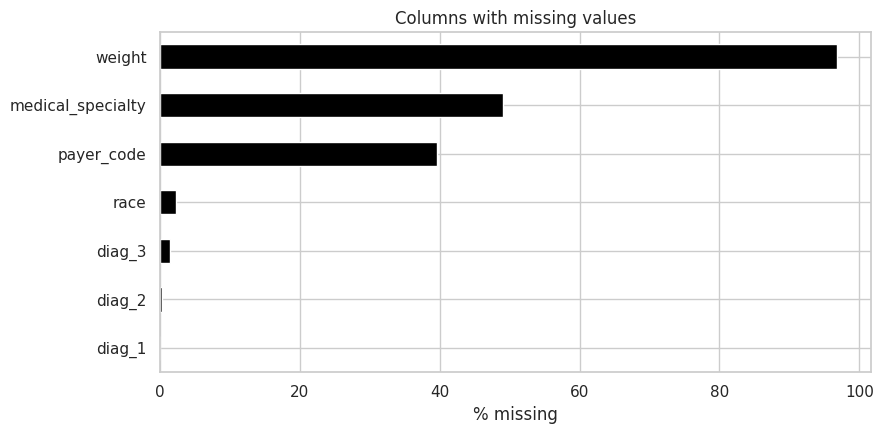

In [5]:
missing = raw.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]
print(missing.round(1))

ax = missing.sort_values().plot.barh(color="black")
ax.set_xlabel("% missing")
ax.set_title("Columns with missing values")
plt.tight_layout(); plt.show()

In [6]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


## 3. Data cleaning

Each step below has a reason:

- **`weight`** is almost entirely missing, so it is dropped.
- **`payer_code`, `medical_specialty`, `race`** have gaps, but "not recorded" can itself carry information, so missing values become the category `Unknown`.
- **Patients who died or went to hospice** cannot be readmitted, so those encounters are removed.
- **One encounter per patient** (the first). Otherwise the same patient appears in both training and test data and the model looks better than it is.
- **Columns with a single value** carry no information and are dropped.

In [7]:
df = raw.copy()
log = [("Start", len(df))]

df = df.drop(columns=["weight"])

for c in ["race", "payer_code", "medical_specialty"]:
    df[c] = df[c].fillna("Unknown")

df = df[df["gender"].isin(["Male", "Female"])]
log.append(("Remove unknown gender", len(df)))

# 11, 19, 20, 21 = expired; 13, 14 = hospice
df = df[~df["discharge_disposition_id"].isin([11, 13, 14, 19, 20, 21])]
log.append(("Remove died / hospice", len(df)))

df = df.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")
log.append(("Keep first encounter per patient", len(df)))

constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
df = df.drop(columns=constant_cols)
print("Dropped constant columns:", constant_cols)

# Target: 1 = readmitted within 30 days
df["readmit_30"] = (df["readmitted"] == "<30").astype(int)

df = df.reset_index(drop=True)
print(pd.DataFrame(log, columns=["Step", "Rows left"]).to_string(index=False))
print("\nRemaining missing values:")
print(df.isna().sum()[df.isna().sum() > 0])

Dropped constant columns: ['examide', 'citoglipton', 'glimepiride-pioglitazone']
                            Step  Rows left
                           Start     101766
           Remove unknown gender     101763
           Remove died / hospice      99340
Keep first encounter per patient      69987

Remaining missing values:
diag_1      10
diag_2     293
diag_3    1224
dtype: int64


## 4. Exploratory data analysis

30-day readmission rate: 9.0%  (6,285 of 69,987 patients)


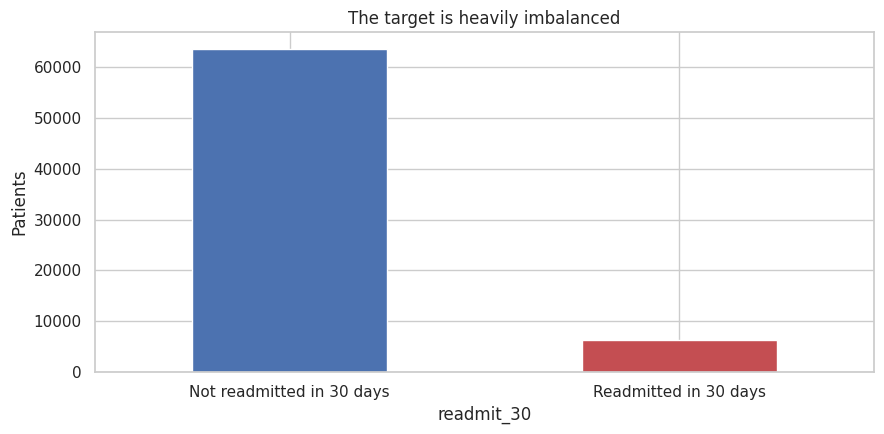

In [8]:
base_rate = df["readmit_30"].mean()
print(f"30-day readmission rate: {base_rate:.1%}  ({df['readmit_30'].sum():,} of {len(df):,} patients)")

ax = df["readmit_30"].map({0: "Not readmitted in 30 days", 1: "Readmitted in 30 days"}).value_counts().plot.bar(
    color=["#4C72B0", "#C44E52"], rot=0)
ax.set_ylabel("Patients"); ax.set_title("The target is heavily imbalanced")
plt.tight_layout(); plt.show()

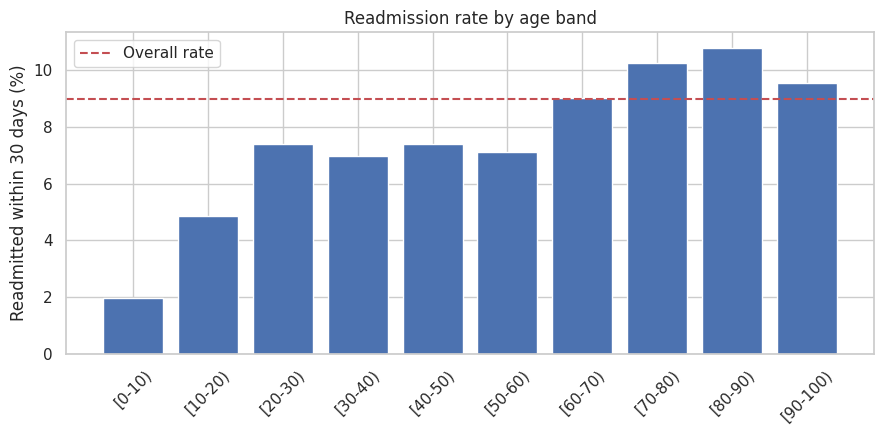

,rate,n
age,,
[0-10),0.019608,153
[10-20),0.048689,534
[20-30),0.074041,1121
[30-40),0.069837,2692
[40-50),0.074107,6828
[50-60),0.071249,12351
[60-70),0.090196,15688
[70-80),0.102372,17749
[80-90),0.107921,11110


In [9]:
def rate_plot(data, col, title=None, min_n=50, sort=False, ax=None):
    """Bar chart of 30-day readmission rate for each value of a column."""
    g = data.groupby(col)["readmit_30"].agg(rate="mean", n="size")
    g = g[g["n"] >= min_n]
    if sort:
        g = g.sort_values("rate")
    own = ax is None
    if own:
        fig, ax = plt.subplots()
    ax.bar(g.index.astype(str), g["rate"] * 100, color="#4C72B0")
    ax.axhline(data["readmit_30"].mean() * 100, color="#C44E52", ls="--", label="Overall rate")
    ax.set_ylabel("Readmitted within 30 days (%)")
    ax.set_title(title or f"Readmission rate by {col}")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    if own:
        plt.tight_layout(); plt.show()
    return g

rate_plot(df, "age", "Readmission rate by age band")

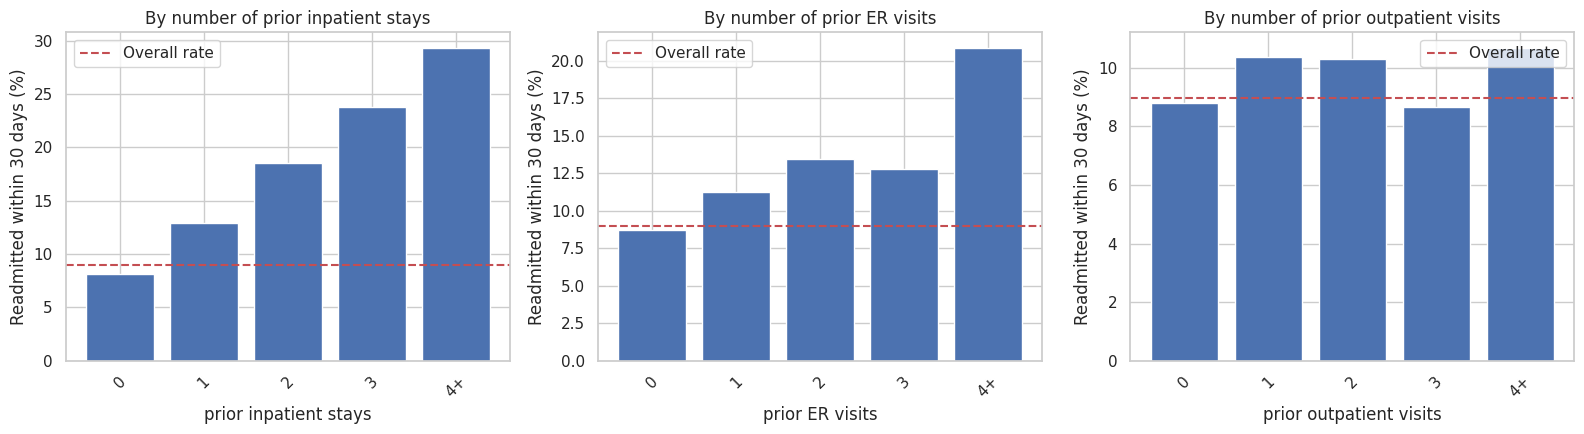

In [10]:
# Prior use of hospital services in the year before this admission
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, label in zip(axes,
        ["number_inpatient", "number_emergency", "number_outpatient"],
        ["prior inpatient stays", "prior ER visits", "prior outpatient visits"]):
    tmp = df.assign(grp=df[col].clip(upper=4).astype(int).astype(str).replace({"4": "4+"}))
    rate_plot(tmp, "grp", f"By number of {label}", ax=ax)
    ax.set_xlabel(label)
plt.tight_layout(); plt.show()

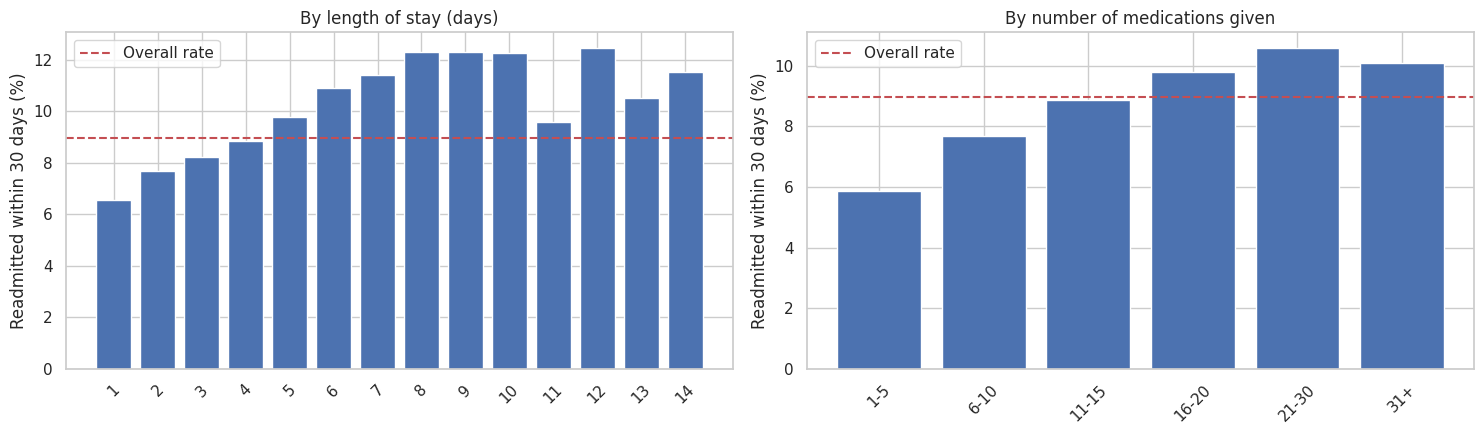

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
rate_plot(df, "time_in_hospital", "By length of stay (days)", ax=axes[0])
tmp = df.assign(meds=pd.cut(df["num_medications"], [0, 5, 10, 15, 20, 30, 100],
                            labels=["1-5", "6-10", "11-15", "16-20", "21-30", "31+"]))
rate_plot(tmp, "meds", "By number of medications given", ax=axes[1])
plt.tight_layout(); plt.show()

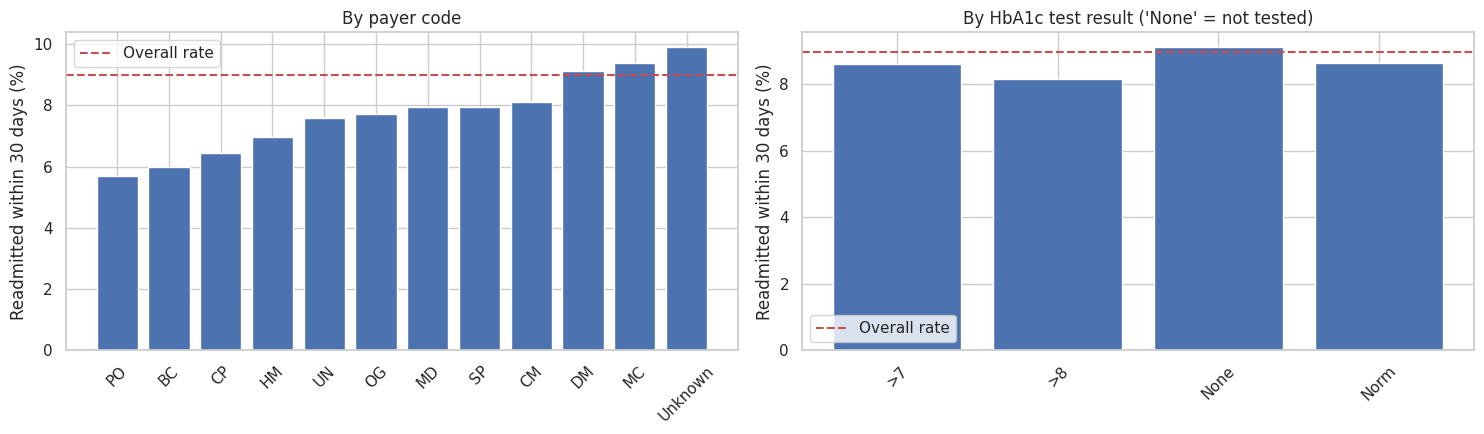

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
rate_plot(df, "payer_code", "By payer code", min_n=200, sort=True, ax=axes[0])
rate_plot(df, "A1Cresult", "By HbA1c test result ('None' = not tested)", ax=axes[1])
plt.tight_layout(); plt.show()

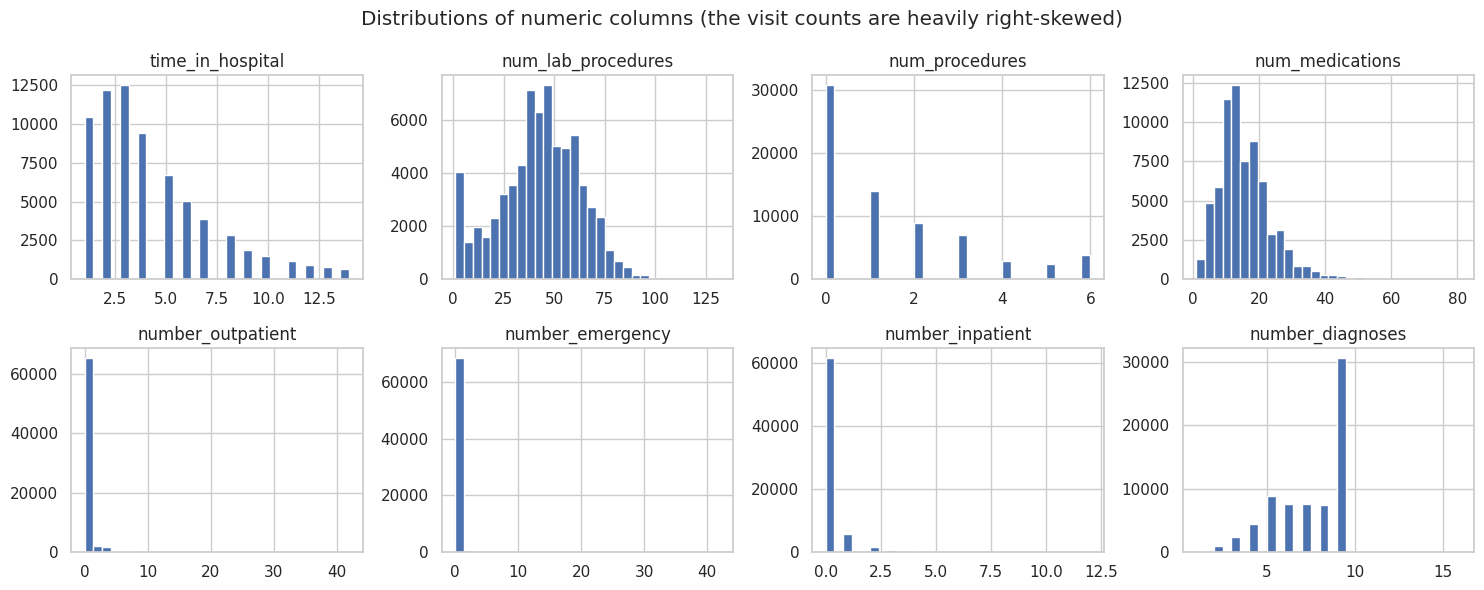

Skewness:
number_emergency      21.23
number_outpatient      9.70
number_inpatient       5.59
num_medications        1.43
num_procedures         1.23
time_in_hospital       1.18
num_lab_procedures    -0.22
number_diagnoses      -0.72
dtype: float64


In [13]:
num_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
            "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]

df[num_cols].hist(bins=30, figsize=(15, 6), layout=(2, 4), color="#4C72B0")
plt.suptitle("Distributions of numeric columns (the visit counts are heavily right-skewed)")
plt.tight_layout(); plt.show()

print("Skewness:")
print(df[num_cols].skew().round(2).sort_values(ascending=False))

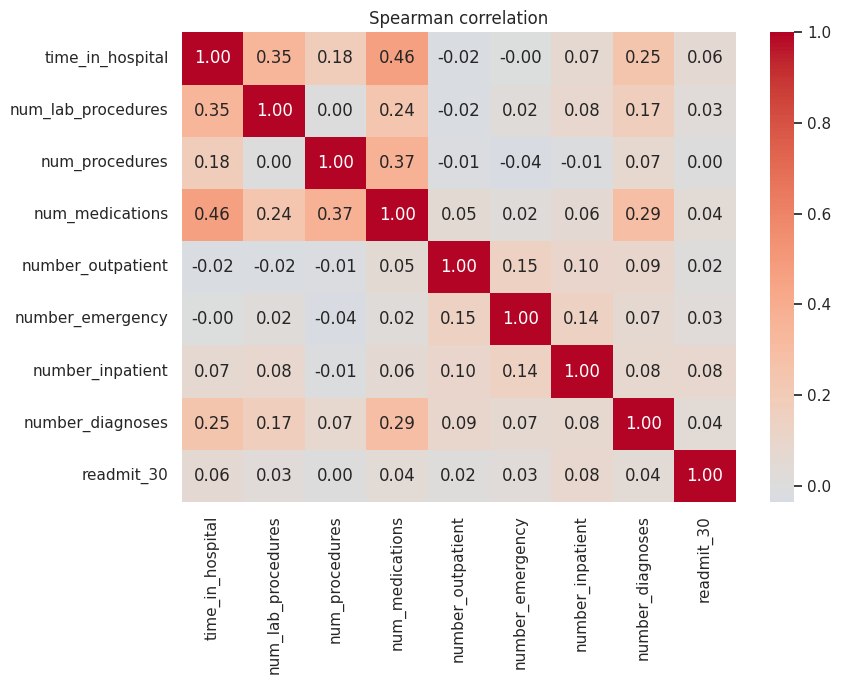

In [14]:
corr = df[num_cols + ["readmit_30"]].corr(method="spearman")
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation")
plt.tight_layout(); plt.show()

## 5. Feature engineering

Raw codes are turned into features a model (and a reader) can use:

- **Age** band → midpoint number
- **ICD-9 diagnosis codes** (hundreds of values) → 9 clinical groups
- **Admission type, discharge destination, admission source** IDs → readable groups
- **Medication columns** → how many diabetes drugs the patient is on, and how many had the dose changed
- **Prior utilisation** → total prior visits and a frequent-ER-user flag

In [15]:
def diag_group(code):
    """Map an ICD-9 code to a broad clinical group."""
    if pd.isna(code) or code == "":
        return "Missing"
    code = str(code)
    if code[0] in ("V", "E"):
        return "Other"
    try:
        x = float(code)
    except ValueError:
        return "Other"
    if 390 <= x <= 459 or int(x) == 785: return "Circulatory"
    if 460 <= x <= 519 or int(x) == 786: return "Respiratory"
    if 520 <= x <= 579 or int(x) == 787: return "Digestive"
    if int(x) == 250:                    return "Diabetes"
    if 800 <= x <= 999:                  return "Injury"
    if 710 <= x <= 739:                  return "Musculoskeletal"
    if 580 <= x <= 629 or int(x) == 788: return "Genitourinary"
    if 140 <= x <= 239:                  return "Neoplasms"
    return "Other"

for c in ["diag_1", "diag_2", "diag_3"]:
    df[c + "_grp"] = df[c].apply(diag_group)

df["age_mid"] = df["age"].str.extract(r"\[(\d+)-")[0].astype(int) + 5

df["admission_type"] = df["admission_type_id"].map(
    {1: "Emergency", 2: "Urgent", 3: "Elective", 4: "Newborn", 7: "Trauma"}).fillna("Unknown")

def discharge_group(i):
    if i == 1: return "Home"
    if i in (6, 8): return "Home with home health"
    if i in (3, 4, 5, 15, 22, 23, 24): return "SNF / rehab / long-term care"
    if i in (2, 9, 10, 27, 28, 29, 30): return "Transfer to another hospital"
    if i == 7: return "Left against medical advice"
    return "Other / unknown"
df["discharge_grp"] = df["discharge_disposition_id"].apply(discharge_group)

def source_group(i):
    if i == 7: return "Emergency room"
    if i in (1, 2, 3): return "Referral"
    if i in (4, 5, 6, 10, 18, 22, 25, 26): return "Transfer"
    return "Other / unknown"
df["admission_src"] = df["admission_source_id"].apply(source_group)

all_meds = ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", "acetohexamide",
            "glipizide", "glyburide", "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
            "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton", "insulin",
            "glyburide-metformin", "glipizide-metformin", "glimepiride-pioglitazone",
            "metformin-rosiglitazone", "metformin-pioglitazone"]
med_cols = [c for c in all_meds if c in df.columns]
df["n_diabetes_meds"] = (df[med_cols] != "No").sum(axis=1)
df["n_meds_changed"] = df[med_cols].isin(["Up", "Down"]).sum(axis=1)

df["med_change"] = (df["change"] == "Ch").astype(int)
df["on_diabetes_med"] = (df["diabetesMed"] == "Yes").astype(int)
df["a1c_tested"] = (df["A1Cresult"] != "None").astype(int)

df["prior_visits_total"] = df["number_inpatient"] + df["number_emergency"] + df["number_outpatient"]
df["frequent_er_user"] = (df["number_emergency"] >= 2).astype(int)

df[["age", "age_mid", "diag_1", "diag_1_grp", "discharge_grp", "admission_src",
    "n_diabetes_meds", "n_meds_changed", "prior_visits_total", "frequent_er_user"]].head()

,age,age_mid,diag_1,diag_1_grp,discharge_grp,admission_src,n_diabetes_meds,n_meds_changed,prior_visits_total,frequent_er_user
0,[80-90),85,398,Circulatory,Home,Transfer,2,0,0,0
1,[90-100),95,434,Circulatory,SNF / rehab / long-term care,Transfer,2,0,0,0
2,[40-50),45,197,Neoplasms,Home,Emergency room,2,0,0,0
3,[40-50),45,250.7,Diabetes,Home,Emergency room,1,0,0,0
4,[50-60),55,414,Circulatory,Home,Referral,1,0,0,0


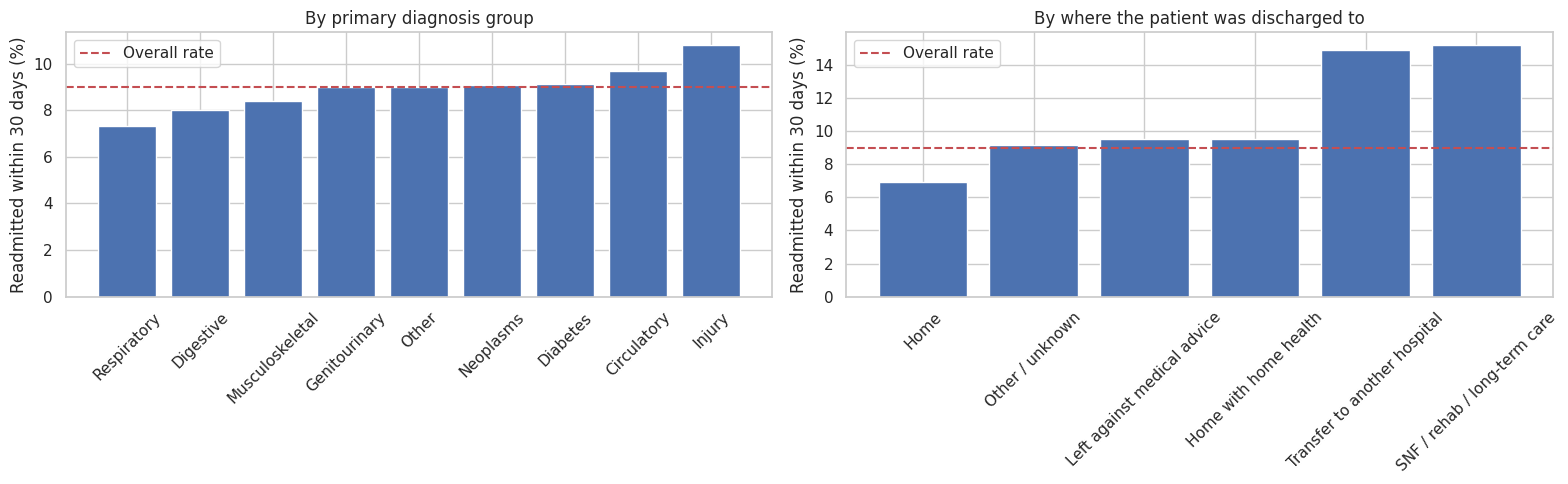

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
rate_plot(df, "diag_1_grp", "By primary diagnosis group", sort=True, ax=axes[0])
rate_plot(df, "discharge_grp", "By where the patient was discharged to", sort=True, ax=axes[1])
plt.tight_layout(); plt.show()

## 6. Frequent ER users — a second problem

A small group of patients uses the ER repeatedly. This section profiles patients with **2 or more ER visits in the previous year** and checks whether they are also the ones who bounce back after discharge.

In [17]:
profile = df.groupby("frequent_er_user").agg(
    patients=("readmit_30", "size"),
    readmit_30_rate=("readmit_30", "mean"),
    avg_age=("age_mid", "mean"),
    avg_prior_inpatient=("number_inpatient", "mean"),
    avg_medications=("num_medications", "mean"),
    avg_diagnoses=("number_diagnoses", "mean"),
    avg_length_of_stay=("time_in_hospital", "mean"),
    pct_admitted_via_er=("admission_src", lambda s: (s == "Emergency room").mean()),
).rename(index={0: "Other patients", 1: "Frequent ER users (2+)"})
profile["share_of_patients"] = profile["patients"] / profile["patients"].sum()
display(profile.T.round(3))

share_pat = df["frequent_er_user"].mean()
share_readm = df.loc[df["readmit_30"] == 1, "frequent_er_user"].mean()
print(f"Frequent ER users are {share_pat:.1%} of patients but {share_readm:.1%} of 30-day readmissions.")

frequent_er_user,Other patients,Frequent ER users (2+)
patients,68769.000,1218.000
readmit_30_rate,0.089,0.144
avg_age,65.538,60.025
avg_prior_inpatient,0.167,0.710
avg_medications,15.662,15.838
avg_diagnoses,7.214,7.781
avg_length_of_stay,4.276,4.130
pct_admitted_via_er,0.530,0.667
share_of_patients,0.983,0.017


Frequent ER users are 1.7% of patients but 2.8% of 30-day readmissions.


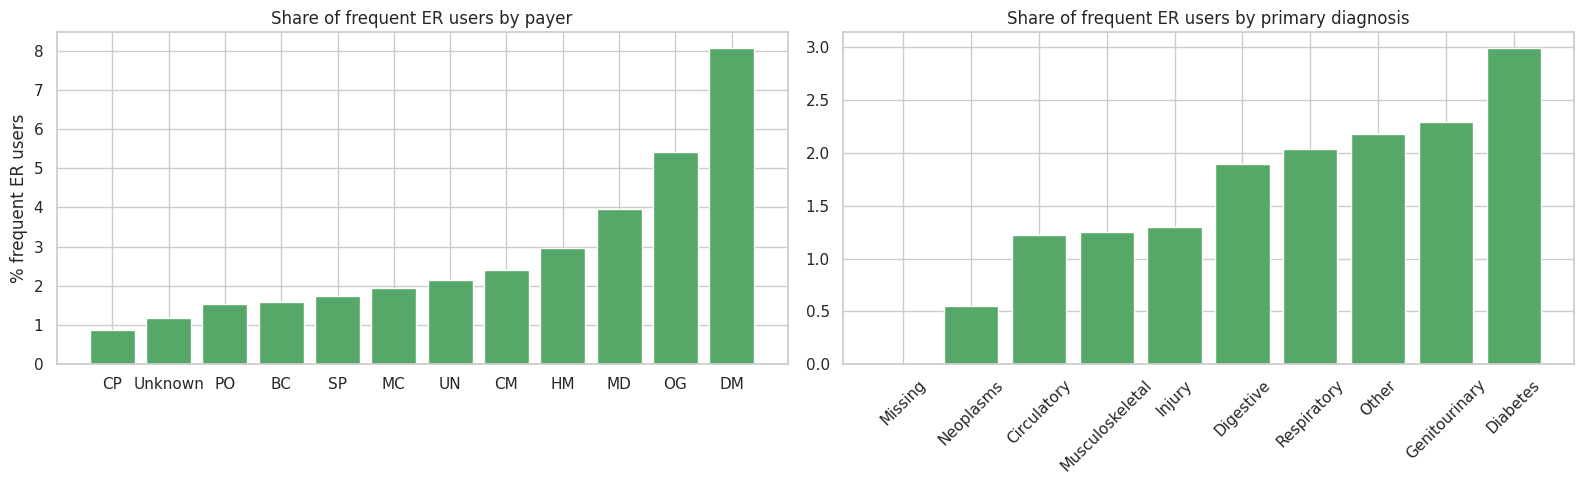

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

er_payer = df.groupby("payer_code")["frequent_er_user"].agg(["mean", "size"])
er_payer = er_payer[er_payer["size"] >= 200].sort_values("mean")
axes[0].bar(er_payer.index, er_payer["mean"] * 100, color="#55A868")
axes[0].set_title("Share of frequent ER users by payer"); axes[0].set_ylabel("% frequent ER users")

er_diag = df.groupby("diag_1_grp")["frequent_er_user"].mean().sort_values()
axes[1].bar(er_diag.index, er_diag * 100, color="#55A868")
axes[1].set_title("Share of frequent ER users by primary diagnosis"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 7. Preprocessing and transformations

- **Log transform (`log1p`)** on the right-skewed counts, then **standard scaling**
- **One-hot encoding** for categories, with rare levels (under 1% of rows) pooled together
- **Stratified 80/20 split** so train and test keep the same readmission rate

Everything sits inside a scikit-learn `Pipeline`, so the transformations are learned from the training data only (no leakage).

In [19]:
skewed_num = ["number_outpatient", "number_emergency", "number_inpatient", "prior_visits_total",
              "num_medications", "num_lab_procedures", "num_procedures", "time_in_hospital", "n_meds_changed"]
plain_num = ["age_mid", "number_diagnoses", "n_diabetes_meds",
             "med_change", "on_diabetes_med", "a1c_tested", "frequent_er_user"]
categorical = ["race", "gender", "payer_code", "medical_specialty", "admission_type", "discharge_grp",
               "admission_src", "diag_1_grp", "diag_2_grp", "diag_3_grp", "max_glu_serum", "A1Cresult"]
categorical += [c for c in ["insulin", "metformin"] if c in df.columns]

features = skewed_num + plain_num + categorical
X = df[features].copy()
y = df["readmit_30"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, f"readmission rate {y_train.mean():.2%}")
print("Test: ", X_test.shape, f"readmission rate {y_test.mean():.2%}")

def make_preprocessor():
    return ColumnTransformer([
        ("skewed", Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                             ("scale", StandardScaler())]), skewed_num),
        ("num", StandardScaler(), plain_num),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01,
                              sparse_output=False), categorical),
    ])

n_out = make_preprocessor().fit(X_train).get_feature_names_out().shape[0]
print(f"{len(features)} input columns become {n_out} model features after encoding.")

Train: (55989, 30) readmission rate 8.98%
Test:  (13998, 30) readmission rate 8.98%
30 input columns become 106 model features after encoding.


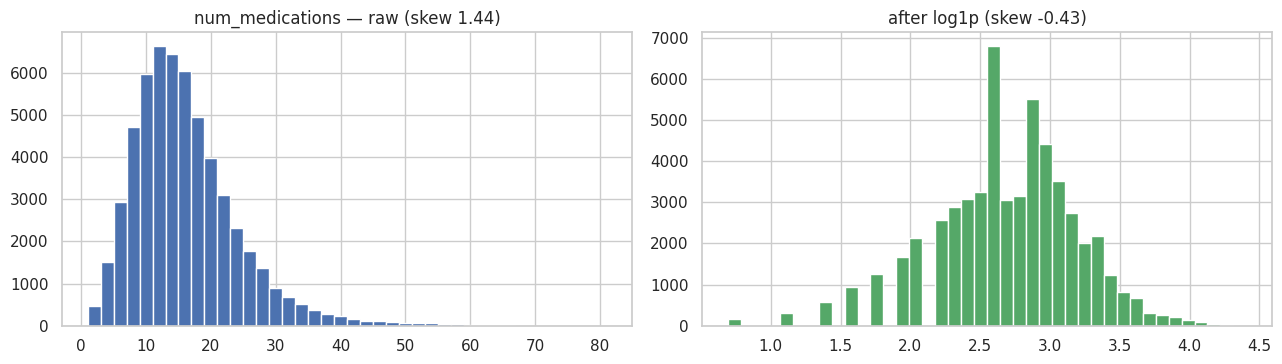

In [20]:
# Effect of the log transform on one skewed column
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
X_train["num_medications"].hist(bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"num_medications — raw (skew {X_train['num_medications'].skew():.2f})")
np.log1p(X_train["num_medications"]).hist(bins=40, ax=axes[1], color="#55A868")
axes[1].set_title(f"after log1p (skew {np.log1p(X_train['num_medications']).skew():.2f})")
plt.tight_layout(); plt.show()

## 8. Machine learning — three models compared

Only about 1 in 11 patients is readmitted, so a model that predicts "nobody is readmitted" already scores around 91% accuracy while being useless. For that reason all three models are trained with **balanced class weights**, and the comparison uses **ROC-AUC, PR-AUC, recall and precision** alongside accuracy.

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20,
                                            class_weight="balanced_subsample", n_jobs=-1,
                                            random_state=RANDOM_STATE),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=5,
                                                        l2_regularization=1.0, random_state=RANDOM_STATE),
}
pipes = {name: Pipeline([("prep", make_preprocessor()), ("model", m)]) for name, m in models.items()}

def fit_pipe(name, pipe, X_, y_):
    # Gradient boosting gets its class balancing through sample weights
    if name == "Gradient Boosting":
        pipe.fit(X_, y_, model__sample_weight=compute_sample_weight("balanced", y_))
    else:
        pipe.fit(X_, y_)
    return pipe

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows, test_proba = [], {}

for name, pipe in pipes.items():
    params = ({"model__sample_weight": compute_sample_weight("balanced", y_train)}
              if name == "Gradient Boosting" else None)
    try:
        cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", params=params)
    except TypeError:   # older scikit-learn
        cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", fit_params=params)

    fit_pipe(name, pipe, X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]
    pred = (p >= 0.5).astype(int)
    test_proba[name] = p
    rows.append({
        "Model": name,
        "CV ROC-AUC (mean)": cv_auc.mean(), "CV ROC-AUC (std)": cv_auc.std(),
        "Test ROC-AUC": roc_auc_score(y_test, p),
        "Test PR-AUC": average_precision_score(y_test, p),
        "Accuracy": accuracy_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred),
    })
    print("done:", name)

results = pd.DataFrame(rows).set_index("Model").round(3)
print(f"\nBaseline — predict 'never readmitted': accuracy {1 - y_test.mean():.3f}, recall 0.000, "
      f"PR-AUC {y_test.mean():.3f}")
results

done: Logistic Regression
done: Random Forest
done: Gradient Boosting

Baseline — predict 'never readmitted': accuracy 0.910, recall 0.000, PR-AUC 0.090


,CV ROC-AUC (mean),CV ROC-AUC (std),Test ROC-AUC,Test PR-AUC,Accuracy,Recall,Precision,F1
Model,,,,,,,,
Logistic Regression,0.641,0.003,0.644,0.156,0.647,0.551,0.137,0.219
Random Forest,0.653,0.006,0.655,0.167,0.726,0.459,0.154,0.231
Gradient Boosting,0.650,0.006,0.649,0.175,0.658,0.539,0.139,0.221


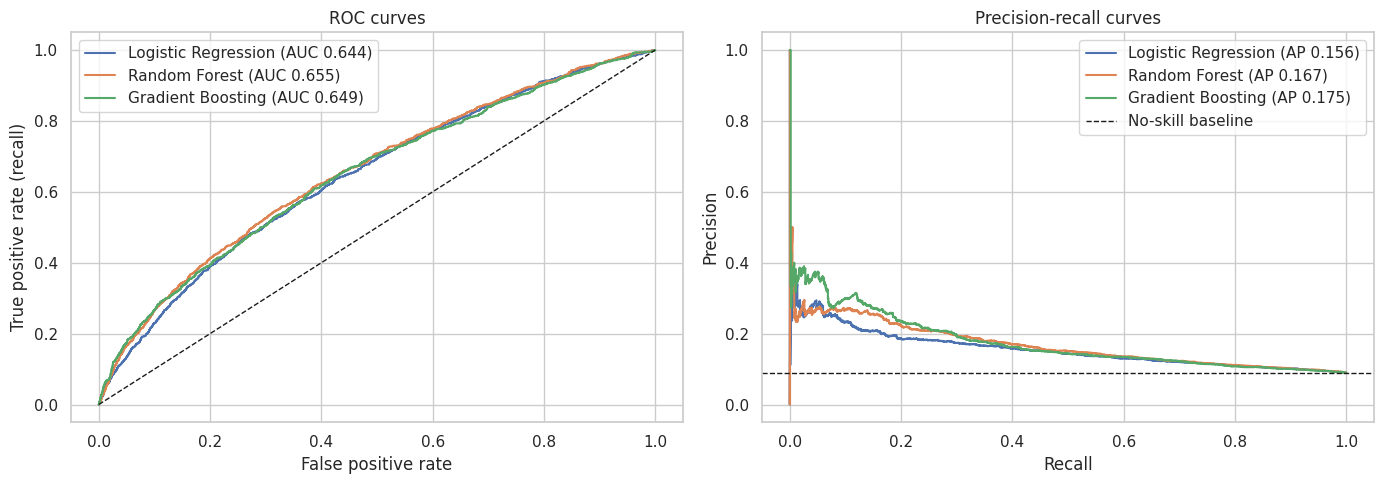

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, p in test_proba.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test, p):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, label=f"{name} (AP {average_precision_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate (recall)", title="ROC curves")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label="No-skill baseline")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curves")
axes[0].legend(); axes[1].legend()
plt.tight_layout(); plt.show()

## 9. Threshold tuning and confusion matrix

A 0.5 cut-off is arbitrary. Here the cut-off for the best model is chosen on the **training data** (using out-of-fold predictions, so the test set stays untouched) and then applied to the test set.

Best model by test ROC-AUC: Random Forest
Threshold that maximises F1 on training folds: 0.510

                 precision    recall  f1-score   support

 Not readmitted      0.933     0.781     0.850     12741
Readmitted <30d      0.163     0.434     0.237      1257

       accuracy                          0.750     13998
      macro avg      0.548     0.607     0.544     13998
   weighted avg      0.864     0.750     0.795     13998



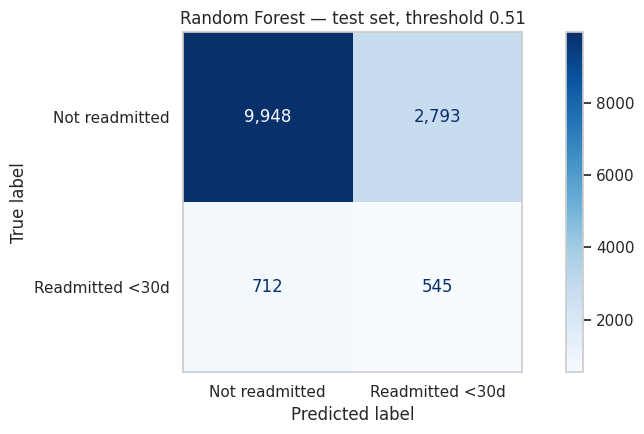

In [23]:
best_name = results["Test ROC-AUC"].idxmax()
best_pipe = pipes[best_name]
print("Best model by test ROC-AUC:", best_name)

params = ({"model__sample_weight": compute_sample_weight("balanced", y_train)}
          if best_name == "Gradient Boosting" else None)
try:
    oof = cross_val_predict(best_pipe, X_train, y_train, cv=cv, method="predict_proba", params=params)[:, 1]
except TypeError:
    oof = cross_val_predict(best_pipe, X_train, y_train, cv=cv, method="predict_proba", fit_params=params)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr = thr[f1s.argmax()]
print(f"Threshold that maximises F1 on training folds: {best_thr:.3f}")

p_best = test_proba[best_name]
pred_best = (p_best >= best_thr).astype(int)
print()
print(classification_report(y_test, pred_best, target_names=["Not readmitted", "Readmitted <30d"], digits=3))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_best),
                       display_labels=["Not readmitted", "Readmitted <30d"]).plot(cmap="Blues", values_format=",")
plt.title(f"{best_name} — test set, threshold {best_thr:.2f}")
plt.grid(False); plt.tight_layout(); plt.show()

## 10. What drives readmission?

**Permutation importance:** shuffle one input column at a time and measure how much the model's ROC-AUC drops. A bigger drop means the model leans on that column more.

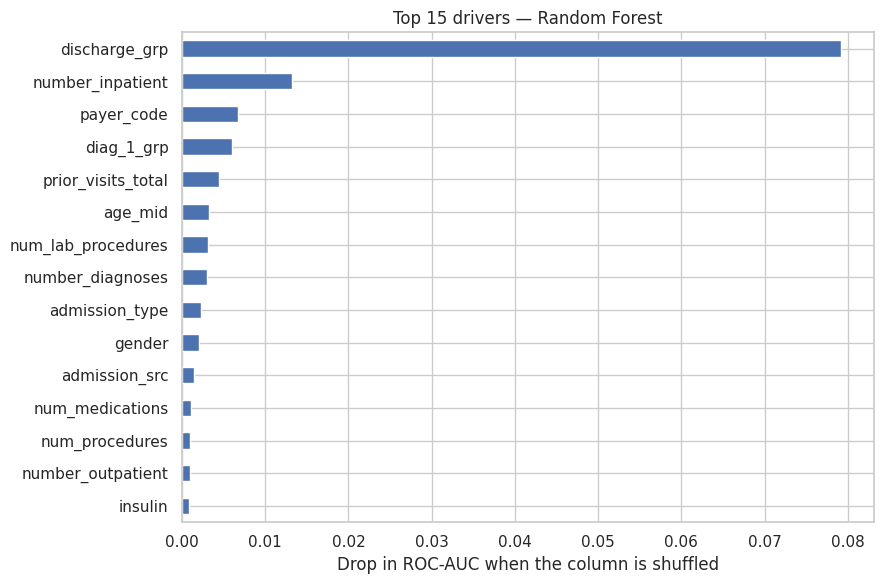

,0
discharge_grp,0.0792
number_inpatient,0.0133
payer_code,0.0067
diag_1_grp,0.0060
prior_visits_total,0.0044
age_mid,0.0032
num_lab_procedures,0.0032
number_diagnoses,0.0030
admission_type,0.0023
gender,0.0020


In [24]:
sample = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE)
perm = permutation_importance(best_pipe, sample, y_test.loc[sample.index], scoring="roc_auc",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)

ax = imp.head(15).sort_values().plot.barh(color="#4C72B0", figsize=(9, 6))
ax.set_xlabel("Drop in ROC-AUC when the column is shuffled")
ax.set_title(f"Top 15 drivers — {best_name}")
plt.tight_layout(); plt.show()
imp.head(15).round(4)

In [25]:
# Direction of effect, from the logistic regression: odds ratio > 1 raises risk, < 1 lowers it
lr = pipes["Logistic Regression"]
coefs = pd.Series(lr.named_steps["model"].coef_[0],
                  index=lr.named_steps["prep"].get_feature_names_out())
odds = np.exp(coefs).sort_values()
pd.concat([odds.tail(10).iloc[::-1].rename("Odds ratio — raises risk").reset_index(),
           odds.head(10).rename("Odds ratio — lowers risk").reset_index()], axis=1).round(2)

,index,Odds ratio — raises risk,index,Odds ratio — lowers risk
0,cat__diag_2_grp_Neoplasms,1.50,cat__medical_specialty_Orthopedics-Reconstructive,0.63
1,cat__discharge_grp_SNF / rehab / long-term care,1.43,cat__discharge_grp_Home,0.65
2,cat__medical_specialty_Nephrology,1.40,cat__metformin_Up,0.77
3,cat__discharge_grp_Transfer to another hospital,1.38,cat__diag_3_grp_Missing,0.81
4,cat__payer_code_Unknown,1.20,cat__payer_code_CP,0.82
5,cat__diag_1_grp_Circulatory,1.20,cat__discharge_grp_Home with home health,0.82
6,cat__medical_specialty_Orthopedics,1.19,cat__discharge_grp_Other / unknown,0.83
7,skewed__number_inpatient,1.18,cat__medical_specialty_Cardiology,0.84
8,cat__metformin_infrequent_sklearn,1.18,cat__diag_2_grp_Musculoskeletal,0.84
9,cat__diag_3_grp_Digestive,1.18,cat__diag_2_grp_Respiratory,0.84


## 11. Risk tiers for a care team

The model is most useful as a ranking tool. Patients in the test set are sorted by predicted risk and split into ten equal groups. If the top groups hold a large share of the real readmissions, follow-up calls and visits can be aimed there.

,patients,readmissions,readmit_rate,lift_vs_average,cumulative_share_of_readmissions
decile,,,,,
1,1400,294,0.210,2.339,0.234
2,1400,194,0.139,1.543,0.388
3,1400,145,0.104,1.153,0.504
4,1399,125,0.089,0.995,0.603
5,1400,103,0.074,0.819,0.685
6,1400,103,0.074,0.819,0.767
7,1399,93,0.066,0.740,0.841
8,1400,79,0.056,0.628,0.904
9,1400,73,0.052,0.581,0.962


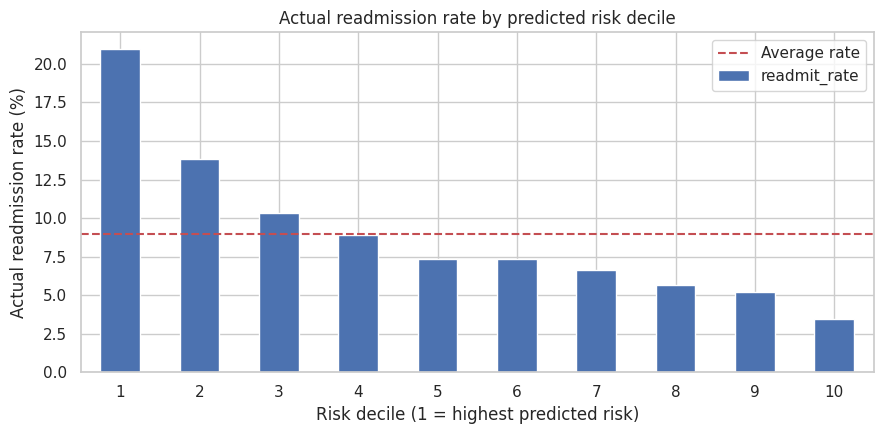

The 20% of patients with the highest predicted risk account for 38.8% of actual 30-day readmissions.


In [26]:
tiers = pd.DataFrame({"risk": p_best, "actual": y_test.values})
tiers["decile"] = pd.qcut(tiers["risk"].rank(method="first", ascending=False), 10, labels=range(1, 11))
lift = tiers.groupby("decile", observed=True).agg(patients=("actual", "size"),
                                                  readmissions=("actual", "sum"),
                                                  readmit_rate=("actual", "mean"))
lift["lift_vs_average"] = lift["readmit_rate"] / tiers["actual"].mean()
lift["cumulative_share_of_readmissions"] = lift["readmissions"].cumsum() / lift["readmissions"].sum()
display(lift.round(3))

ax = (lift["readmit_rate"] * 100).plot.bar(color="#4C72B0", rot=0)
ax.axhline(tiers["actual"].mean() * 100, color="#C44E52", ls="--", label="Average rate")
ax.set(xlabel="Risk decile (1 = highest predicted risk)", ylabel="Actual readmission rate (%)",
       title="Actual readmission rate by predicted risk decile")
ax.legend(); plt.tight_layout(); plt.show()

top20 = lift["cumulative_share_of_readmissions"].iloc[1]
print(f"The 20% of patients with the highest predicted risk account for {top20:.1%} of actual 30-day readmissions.")

In [27]:
# Save the fitted pipeline so it can be reused without retraining
joblib.dump(best_pipe, "readmission_model.joblib")
print("Saved readmission_model.joblib")

Saved readmission_model.joblib


## 12. Summary of findings

In [28]:
def rate(mask):
    return df.loc[mask, "readmit_30"].mean()

best = results.loc[best_name]
print("DATA")
print(f"  {len(raw):,} encounters -> {len(df):,} patients after cleaning")
print(f"  30-day readmission rate: {base_rate:.1%}")
print()
print("FINDINGS")
print(f"  1. Prior inpatient stays: {rate(df.number_inpatient == 0):.1%} readmitted with none "
      f"vs {rate(df.number_inpatient >= 2):.1%} with two or more")
print(f"  2. Frequent ER users (2+ visits): {share_pat:.1%} of patients, {share_readm:.1%} of readmissions, "
      f"readmission rate {rate(df.frequent_er_user == 1):.1%} vs {rate(df.frequent_er_user == 0):.1%}")
dg = df.groupby("discharge_grp")["readmit_30"].agg(["mean", "size"])
dg = dg[dg["size"] >= 50]["mean"]
print(f"  3. Discharge destination: highest '{dg.idxmax()}' ({dg.max():.1%}), lowest '{dg.idxmin()}' ({dg.min():.1%})")
print(f"  4. Length of stay: {rate(df.time_in_hospital <= 2):.1%} for 1-2 days vs {rate(df.time_in_hospital >= 8):.1%} for 8+ days")
print(f"  5. Top model drivers: {', '.join(imp.head(5).index)}")
print()
print("MODEL")
print(f"  Best model: {best_name}")
print(f"  Test ROC-AUC {best['Test ROC-AUC']:.3f}, PR-AUC {best['Test PR-AUC']:.3f} (no-skill PR-AUC {y_test.mean():.3f})")
print(f"  At threshold {best_thr:.2f}: recall {recall_score(y_test, pred_best):.1%}, "
      f"precision {precision_score(y_test, pred_best, zero_division=0):.1%}, "
      f"accuracy {accuracy_score(y_test, pred_best):.1%}")
print(f"  Top 20% highest-risk patients hold {top20:.1%} of readmissions")

DATA
  101,766 encounters -> 69,987 patients after cleaning
  30-day readmission rate: 9.0%

FINDINGS
  1. Prior inpatient stays: 8.1% readmitted with none vs 21.5% with two or more
  2. Frequent ER users (2+ visits): 1.7% of patients, 2.8% of readmissions, readmission rate 14.4% vs 8.9%
  3. Discharge destination: highest 'SNF / rehab / long-term care' (15.2%), lowest 'Home' (6.9%)
  4. Length of stay: 7.2% for 1-2 days vs 11.8% for 8+ days
  5. Top model drivers: discharge_grp, number_inpatient, payer_code, diag_1_grp, prior_visits_total

MODEL
  Best model: Random Forest
  Test ROC-AUC 0.655, PR-AUC 0.167 (no-skill PR-AUC 0.090)
  At threshold 0.51: recall 43.4%, precision 16.3%, accuracy 75.0%
  Top 20% highest-risk patients hold 38.8% of readmissions


### How a care team could use this

- **Prioritise follow-up by risk tier.** Give the top one or two deciles a call within 48 hours of discharge and a primary-care appointment within 7 days.
- **Flag frequent ER users at admission.** Two or more ER visits in the past year is known on day one, before any model runs.
- **Look closely at the discharge destination.** Check the chart in section 5 for which destinations sit above the average line; those hand-offs are where medication reconciliation and warm hand-overs matter most.
- **Review long stays and heavy medication lists before discharge**, since both go with higher return rates.

### Limits to keep in mind

- The data is from 1999–2008 and covers diabetic inpatients only, so the numbers describe that group.
- Readmission is hard to predict from administrative data. Published models on this dataset usually land around 0.62–0.68 ROC-AUC, so treat the model as a way to rank patients, not as a yes/no verdict.
- The associations here are correlations. A longer stay does not cause readmission; sicker patients have both.

### Ideas for extending it

- Try XGBoost or LightGBM with hyperparameter tuning (`RandomizedSearchCV`)
- Add SHAP values for patient-level explanations
- Predict frequent ER use as its own target
- Repeat the workflow on CMS synthetic Medicare claims (DE-SynPUF) for a true line-level claims dataset

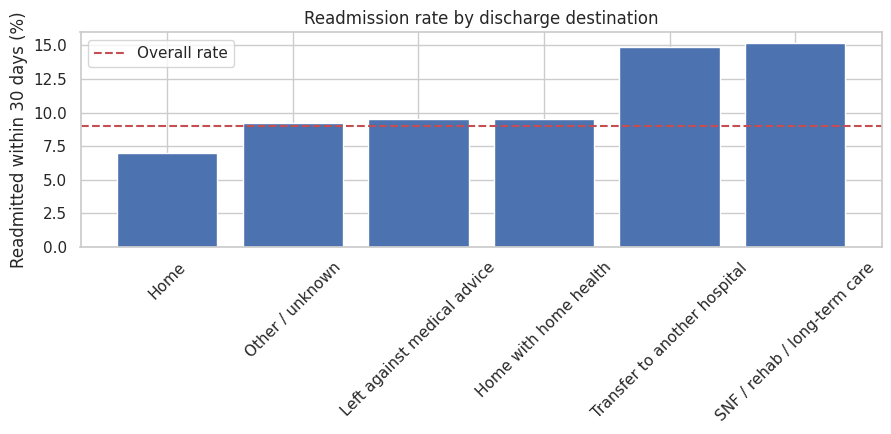

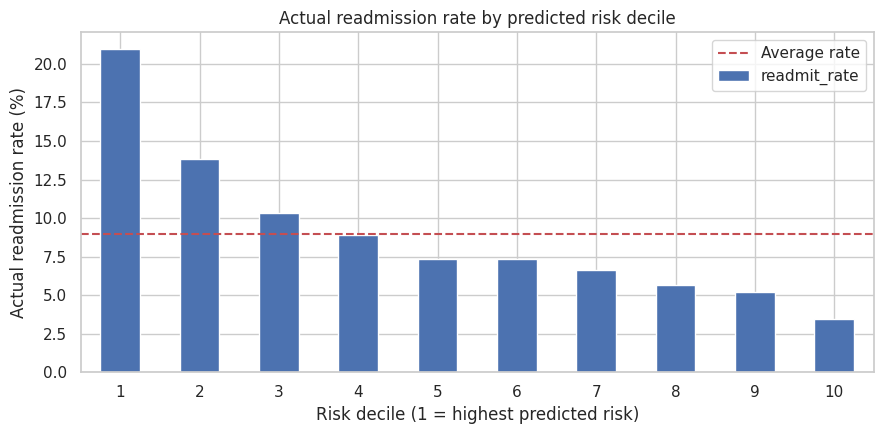

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import os
os.makedirs("images", exist_ok=True)

# Readmission rate by discharge destination
fig, ax = plt.subplots(figsize=(9, 4.5))
rate_plot(df, "discharge_grp", "Readmission rate by discharge destination", sort=True, ax=ax)
plt.tight_layout(); fig.savefig("images/discharge.png", dpi=120); plt.show()

# Risk deciles
fig, ax = plt.subplots(figsize=(9, 4.5))
(lift["readmit_rate"] * 100).plot.bar(color="#4C72B0", rot=0, ax=ax)
ax.axhline(tiers["actual"].mean() * 100, color="#C44E52", ls="--", label="Average rate")
ax.set(xlabel="Risk decile (1 = highest predicted risk)", ylabel="Actual readmission rate (%)",
       title="Actual readmission rate by predicted risk decile")
ax.legend(); plt.tight_layout(); fig.savefig("images/risk_deciles.png", dpi=120); plt.show()

from google.colab import files
files.download("images/discharge.png")
files.download("images/risk_deciles.png")